<a href="https://colab.research.google.com/github/Ijo2004/Crushathon/blob/main/KNN_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN) for Fashion MNIST Classification

This notebook implements **K-Nearest Neighbors (KNN)** for multi-class image classification on the **Fashion MNIST** dataset, experiments with different values of **K**, and analyzes the impact of K on accuracy and computational efficiency.

**Contents**
1. Setup
2. Load & explore the Fashion MNIST dataset
3. Preprocessing (normalization, flattening, dimensionality reduction, subsampling)
4. KNN from scratch (educational, small-scale demo)
5. KNN with scikit-learn (main experiments)
6. Experimenting with different K values
7. Evaluation: accuracy, confusion matrix, classification report
8. Computational efficiency analysis (train/predict time vs. K)
9. Discussion & conclusions

> **Tip:** In Colab, go to `Runtime > Change runtime type` and select a GPU/TPU if you want faster TensorFlow data loading — KNN itself runs on CPU via scikit-learn.


## 1. Setup
Install/import the libraries we need.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import time

# scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

# TensorFlow/Keras is used only to conveniently download Fashion MNIST
import tensorflow as tf

np.random.seed(42)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load & Explore the Fashion MNIST Dataset

Fashion MNIST contains **70,000 grayscale images** (28x28 pixels) of clothing items across **10 classes**:
`T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot`.

- 60,000 training images
- 10,000 test images


In [2]:
# Load the dataset (downloads automatically the first time)
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training set:", X_train_full.shape, y_train_full.shape)
print("Test set:    ", X_test_full.shape, y_test_full.shape)
print("Pixel value range:", X_train_full.min(), "-", X_train_full.max())


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28) (60000,)
Test set:     (10000, 28, 28) (10000,)
Pixel value range: 0 - 255


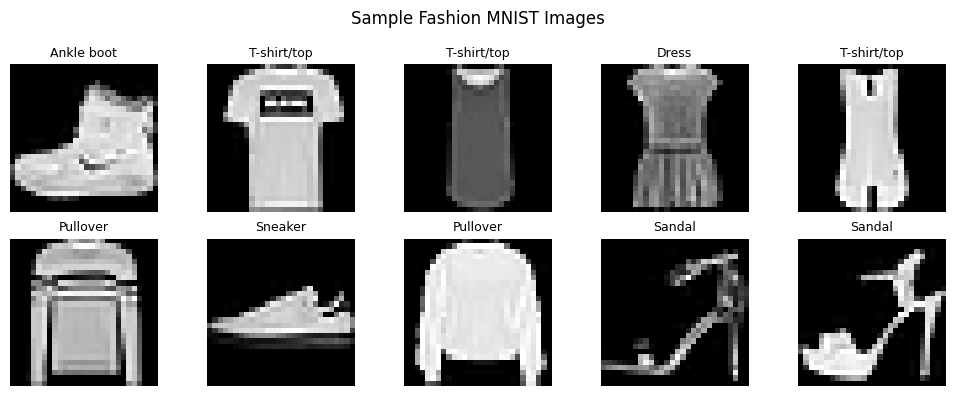

In [3]:
# Visualize a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap="gray")
    ax.set_title(class_names[y_train_full[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Fashion MNIST Images")
plt.tight_layout()
plt.show()


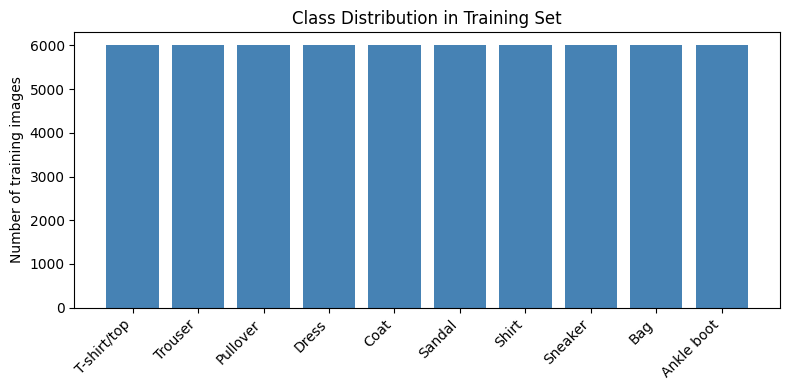

In [4]:
# Class distribution (sanity check for class balance)
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[u] for u in unique], counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of training images")
plt.title("Class Distribution in Training Set")
plt.tight_layout()
plt.show()


## 3. Preprocessing

KNN is a **distance-based, lazy-learning** algorithm: it has no training phase, but prediction requires computing distances to (a subset of) stored training points. This makes it:

- **Sensitive to feature scale** → we normalize pixel values to `[0, 1]`.
- **Sensitive to dimensionality** ("curse of dimensionality") and **slow at prediction time** on large datasets → we:
  1. **Flatten** each 28x28 image into a 784-dim vector.
  2. Optionally apply **PCA** to reduce dimensionality while retaining most of the variance (speeds up distance computation and often improves accuracy by removing noisy pixels).
  3. **Subsample** the training set to a manageable size so experiments finish in reasonable time on a CPU. Feel free to increase `N_TRAIN`/`N_TEST` if you have more time/compute.


In [5]:
# --- Flatten and normalize ---
X_train_flat = X_train_full.reshape(len(X_train_full), -1).astype("float32") / 255.0
X_test_flat = X_test_full.reshape(len(X_test_full), -1).astype("float32") / 255.0

y_train_all = y_train_full.copy()
y_test_all = y_test_full.copy()

print("Flattened shapes:", X_train_flat.shape, X_test_flat.shape)


Flattened shapes: (60000, 784) (10000, 784)


In [6]:
# --- Subsample for computational tractability ---
# Brute-force KNN prediction cost scales with (n_train * n_test * n_features),
# so we work with a representative subset. Increase these if you have more time/compute.
N_TRAIN = 6000
N_TEST = 1000

train_idx = np.random.choice(len(X_train_flat), N_TRAIN, replace=False)
test_idx = np.random.choice(len(X_test_flat), N_TEST, replace=False)

X_train_sub = X_train_flat[train_idx]
y_train_sub = y_train_all[train_idx]
X_test_sub = X_test_flat[test_idx]
y_test_sub = y_test_all[test_idx]

print("Subsampled training set:", X_train_sub.shape)
print("Subsampled test set:    ", X_test_sub.shape)


Subsampled training set: (6000, 784)
Subsampled test set:     (1000, 784)


Explained variance retained: 86.45%
Reduced shape: (6000, 50)


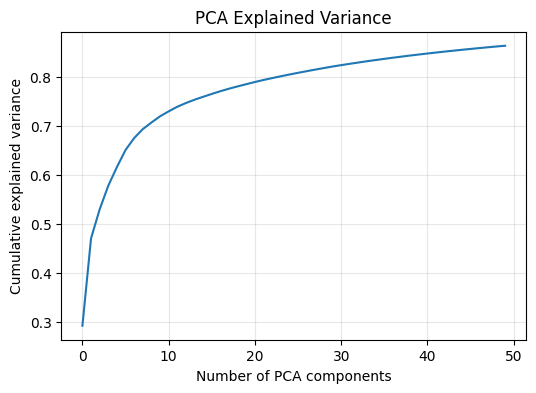

In [7]:
# --- Dimensionality reduction with PCA ---
# Reduce 784 dims down to a smaller number of components that retain most variance.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_sub)
X_test_pca = pca.transform(X_test_sub)

print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")
print("Reduced shape:", X_train_pca.shape)

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(alpha=0.3)
plt.show()


## 4. KNN From Scratch (Educational Demo)

To make sure we understand the algorithm, here is a simple NumPy implementation of KNN using Euclidean distance and majority voting. It's run on a very small slice of data (it's O(n_train x n_test) in pure NumPy, so it doesn't scale to the full experiments — the scikit-learn version in Section 5 is used for the main experiments).


In [8]:
def knn_predict_scratch(X_train, y_train, X_query, k=5):
    """
    Simple KNN classifier implemented from scratch.
    X_train: (n_train, n_features)
    y_train: (n_train,)
    X_query: (n_query, n_features)
    Returns predicted labels for X_query using majority vote of k nearest neighbors.
    """
    predictions = []
    for q in X_query:
        # Euclidean distance from q to every training point
        dists = np.sqrt(np.sum((X_train - q) ** 2, axis=1))
        nearest_idx = np.argsort(dists)[:k]
        nearest_labels = y_train[nearest_idx]
        # Majority vote
        values, counts = np.unique(nearest_labels, return_counts=True)
        predictions.append(values[np.argmax(counts)])
    return np.array(predictions)

# Demo on a small slice (200 train / 30 query) just to confirm correctness
demo_preds = knn_predict_scratch(
    X_train_pca[:200], y_train_sub[:200], X_test_pca[:30], k=5
)
demo_acc = accuracy_score(y_test_sub[:30], demo_preds)
print(f"From-scratch KNN demo accuracy (tiny subset, k=5): {demo_acc:.2%}")


From-scratch KNN demo accuracy (tiny subset, k=5): 70.00%


## 5. KNN with scikit-learn (Main Experiments)

We use `sklearn.neighbors.KNeighborsClassifier`, which is a highly optimized implementation (supports KD-tree / Ball-tree / brute-force search) and scales far better than the from-scratch version above. This is what we use for all the real experiments below.


In [9]:
# Baseline model with a default K
knn_baseline = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

start = time.time()
knn_baseline.fit(X_train_pca, y_train_sub)
train_time = time.time() - start

start = time.time()
y_pred_baseline = knn_baseline.predict(X_test_pca)
predict_time = time.time() - start

baseline_acc = accuracy_score(y_test_sub, y_pred_baseline)
print(f"Baseline KNN (k=5) accuracy: {baseline_acc:.2%}")
print(f"Fit time:     {train_time:.4f} s")
print(f"Predict time: {predict_time:.4f} s")


Baseline KNN (k=5) accuracy: 81.50%
Fit time:     0.0065 s
Predict time: 0.2906 s


## 6. Experimenting with Different K Values

We now sweep K over a range of odd values (odd K avoids tie votes in binary-leaning decisions and is common practice) and record, for each K:
- Test accuracy
- Training ("fit") time
- Prediction time


In [10]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

results = {
    "k": [],
    "accuracy": [],
    "fit_time": [],
    "predict_time": [],
}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    t0 = time.time()
    model.fit(X_train_pca, y_train_sub)
    fit_t = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test_pca)
    pred_t = time.time() - t0

    acc = accuracy_score(y_test_sub, y_pred)

    results["k"].append(k)
    results["accuracy"].append(acc)
    results["fit_time"].append(fit_t)
    results["predict_time"].append(pred_t)

    print(f"K={k:>3} | Accuracy={acc:.4f} | Fit time={fit_t:.4f}s | Predict time={pred_t:.4f}s")


K=  1 | Accuracy=0.7960 | Fit time=0.0052s | Predict time=0.2075s
K=  3 | Accuracy=0.7990 | Fit time=0.0022s | Predict time=0.0875s
K=  5 | Accuracy=0.8150 | Fit time=0.0044s | Predict time=0.1112s
K=  7 | Accuracy=0.8210 | Fit time=0.0025s | Predict time=0.1037s
K=  9 | Accuracy=0.8200 | Fit time=0.0021s | Predict time=0.1125s
K= 11 | Accuracy=0.8180 | Fit time=0.0024s | Predict time=0.0781s
K= 15 | Accuracy=0.8100 | Fit time=0.0021s | Predict time=0.1252s
K= 21 | Accuracy=0.7980 | Fit time=0.0024s | Predict time=0.1045s
K= 31 | Accuracy=0.7770 | Fit time=0.0022s | Predict time=0.1006s
K= 51 | Accuracy=0.7710 | Fit time=0.0027s | Predict time=0.1116s


In [11]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df


,k,accuracy,fit_time,predict_time
0,1,0.796,0.005215,0.207464
1,3,0.799,0.002221,0.087510
2,5,0.815,0.004381,0.111205
3,7,0.821,0.002512,0.103701
4,9,0.820,0.002129,0.112519
5,11,0.818,0.002361,0.078058
6,15,0.810,0.002101,0.125157
7,21,0.798,0.002356,0.104455
8,31,0.777,0.002230,0.100568
9,51,0.771,0.002663,0.111641


## 7. Visualizing Accuracy vs. K

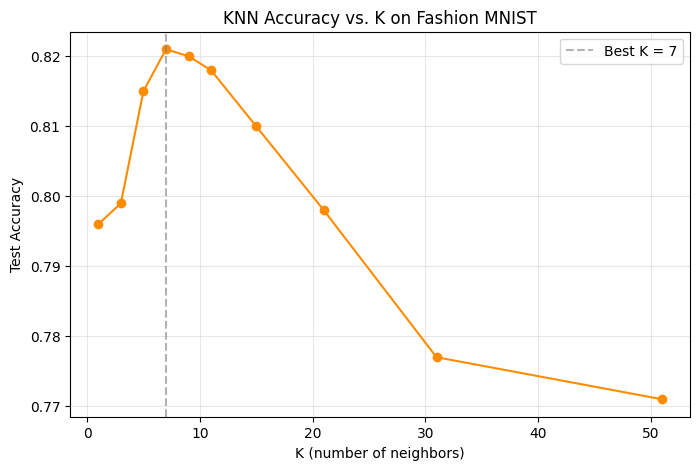

Best K found: 7 with accuracy 0.8210


In [12]:
best_k = results_df.loc[results_df["accuracy"].idxmax(), "k"]

plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o", color="darkorange")
plt.axvline(best_k, color="gray", linestyle="--", alpha=0.6, label=f"Best K = {int(best_k)}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs. K on Fashion MNIST")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Best K found: {int(best_k)} with accuracy {results_df['accuracy'].max():.4f}")


## 8. Computational Efficiency: Fit/Predict Time vs. K

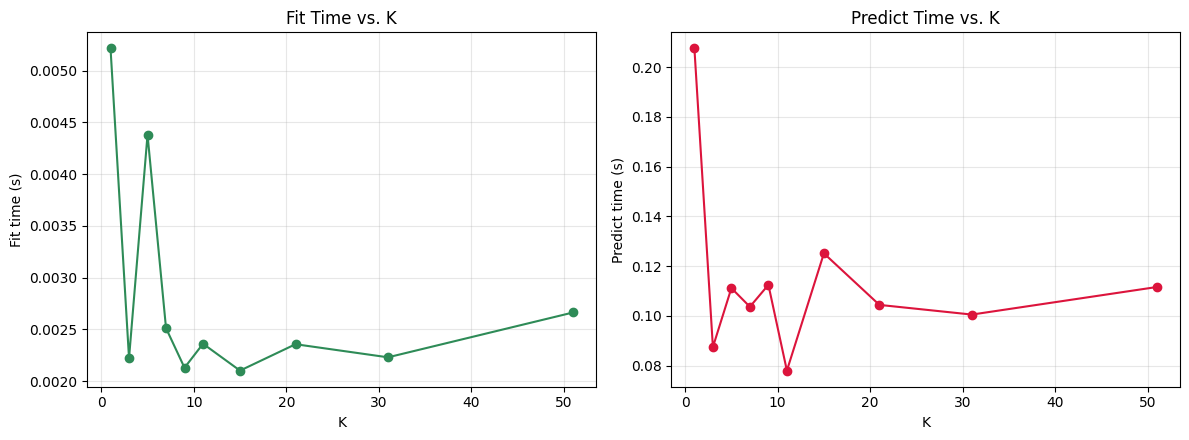

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(results_df["k"], results_df["fit_time"], marker="o", color="seagreen")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("Fit Time vs. K")
axes[0].grid(alpha=0.3)

axes[1].plot(results_df["k"], results_df["predict_time"], marker="o", color="crimson")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Predict time (s)")
axes[1].set_title("Predict Time vs. K")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Detailed Evaluation for the Best K

Confusion matrix and per-class precision/recall/F1 for the best-performing K found above.


In [14]:
best_model = KNeighborsClassifier(n_neighbors=int(best_k), n_jobs=-1)
best_model.fit(X_train_pca, y_train_sub)
y_pred_best = best_model.predict(X_test_pca)

print(classification_report(y_test_sub, y_pred_best, target_names=class_names))


              precision    recall  f1-score   support

 T-shirt/top       0.77      0.77      0.77       117
     Trouser       1.00      0.94      0.97        94
    Pullover       0.69      0.83      0.76        90
       Dress       0.80      0.88      0.84        86
        Coat       0.84      0.73      0.78       114
      Sandal       0.91      0.78      0.84        90
       Shirt       0.58      0.56      0.57        94
     Sneaker       0.87      0.91      0.89        98
         Bag       0.93      0.88      0.91       112
  Ankle boot       0.84      0.93      0.88       105

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.83      0.82      0.82      1000



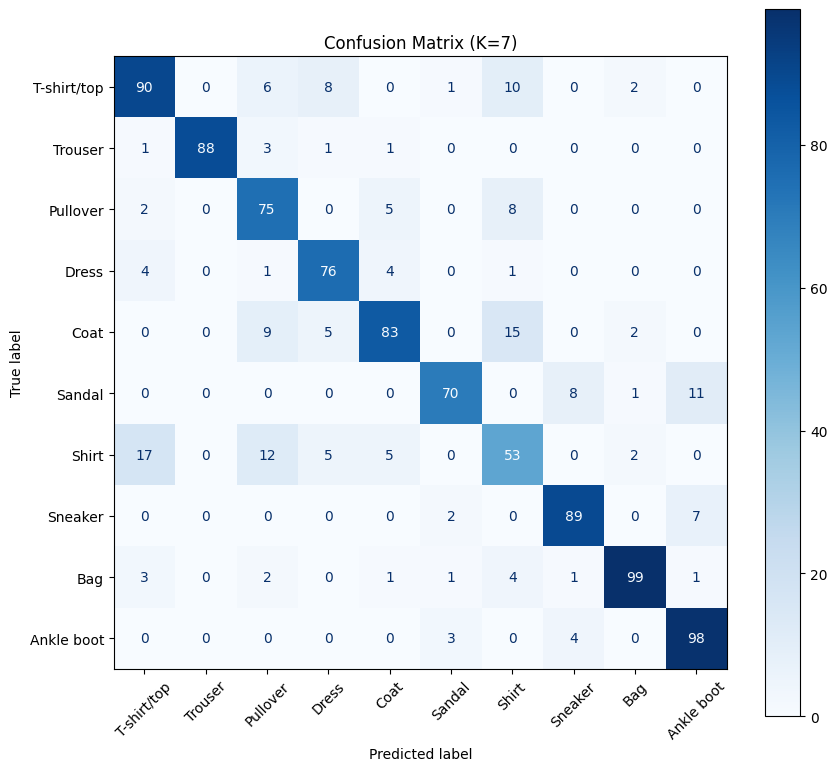

In [15]:
cm = confusion_matrix(y_test_sub, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title(f"Confusion Matrix (K={int(best_k)})")
plt.tight_layout()
plt.show()


Number of misclassified test images: 179 / 1000


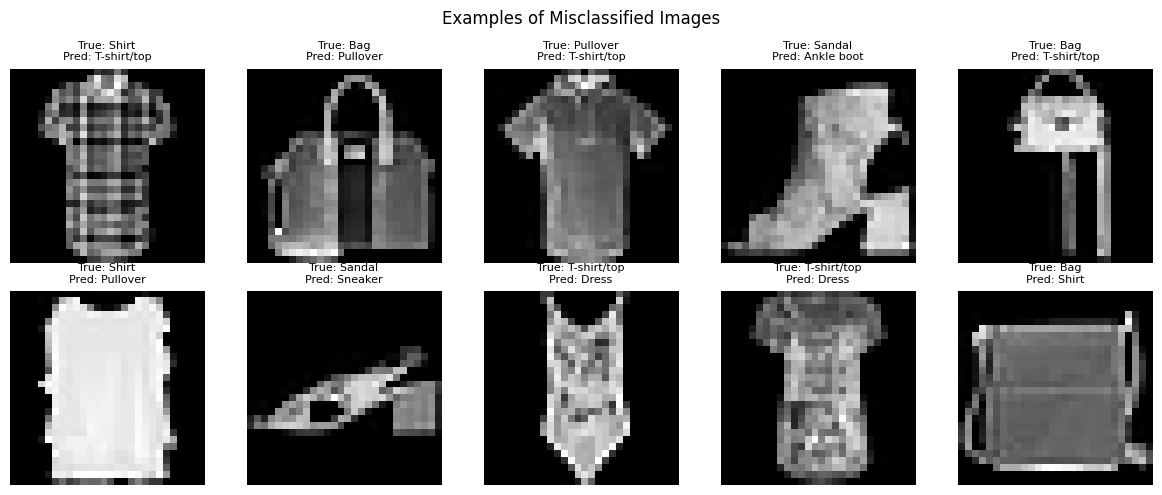

In [16]:
# Show a handful of misclassified examples
misclassified = np.where(y_pred_best != y_test_sub)[0]
print(f"Number of misclassified test images: {len(misclassified)} / {len(y_test_sub)}")

n_show = min(10, len(misclassified))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, misclassified[:n_show]):
    orig_idx = test_idx[idx]
    ax.imshow(X_test_full[orig_idx], cmap="gray")
    true_label = class_names[y_test_sub[idx]]
    pred_label = class_names[y_pred_best[idx]]
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)
    ax.axis("off")
plt.suptitle("Examples of Misclassified Images")
plt.tight_layout()
plt.show()


## 10. Effect of Training Set Size (Bonus)

KNN's cost and accuracy both depend heavily on how much training data it has to search through. Here we fix K at the best value found above and vary the number of training samples to see the trade-off between accuracy and predict time.


In [17]:
train_sizes = [500, 1000, 2000, 4000, 6000]
size_results = {"train_size": [], "accuracy": [], "predict_time": []}

for n in train_sizes:
    model = KNeighborsClassifier(n_neighbors=int(best_k), n_jobs=-1)
    model.fit(X_train_pca[:n], y_train_sub[:n])

    t0 = time.time()
    preds = model.predict(X_test_pca)
    pred_t = time.time() - t0

    acc = accuracy_score(y_test_sub, preds)
    size_results["train_size"].append(n)
    size_results["accuracy"].append(acc)
    size_results["predict_time"].append(pred_t)
    print(f"Train size={n:>5} | Accuracy={acc:.4f} | Predict time={pred_t:.4f}s")

size_df = pd.DataFrame(size_results)


Train size=  500 | Accuracy=0.7410 | Predict time=0.0170s
Train size= 1000 | Accuracy=0.7580 | Predict time=0.0330s
Train size= 2000 | Accuracy=0.7800 | Predict time=0.0270s
Train size= 4000 | Accuracy=0.8020 | Predict time=0.0782s
Train size= 6000 | Accuracy=0.8210 | Predict time=0.0812s


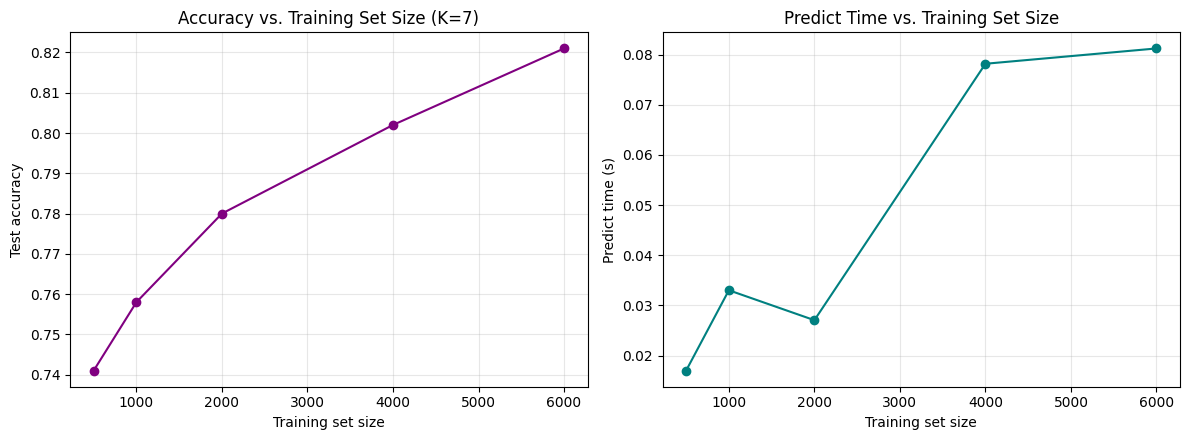

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(size_df["train_size"], size_df["accuracy"], marker="o", color="purple")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title(f"Accuracy vs. Training Set Size (K={int(best_k)})")
axes[0].grid(alpha=0.3)

axes[1].plot(size_df["train_size"], size_df["predict_time"], marker="o", color="teal")
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Predict time (s)")
axes[1].set_title("Predict Time vs. Training Set Size")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Discussion: Impact of K on Accuracy and Computational Efficiency

**Impact on accuracy (bias-variance trade-off)**
- **Very small K (e.g., K=1):** The model follows the training data very closely (low bias, high variance). It is highly sensitive to noise and outliers — a single mislabeled or unusual neighbor can flip a prediction. This often leads to overfitting: good performance on training data but noisier, less stable performance on the test set.
- **Moderate K (e.g., K=5 to K=15, dataset-dependent):** Predictions are smoothed by averaging over several neighbors, which typically reduces variance and improves generalization. This is usually where the best test accuracy is found, as seen in the accuracy-vs-K curve above.
- **Very large K:** The decision boundary becomes overly smooth (high bias, low variance) and starts to ignore local structure in the data. In the extreme, if K approaches the size of the training set, the model essentially just predicts the majority class for every input, and accuracy collapses toward the class-prior baseline.
- The optimal K is dataset-dependent and is typically found via cross-validation (or, as done here, a validation sweep) rather than guessed in advance.

**Impact on computational efficiency**
- **Training ("fit") time** for KNN is trivial regardless of K — KNN is a *lazy learner*: "fitting" mostly just stores the training data (or builds an index structure like a KD-tree/Ball-tree). It does not depend meaningfully on K.
- **Prediction time** is where K and dataset size matter:
  - The dominant cost is computing distances from each query point to (potentially) every training point — this scales with the number of training samples and the number of features (dimensionality), which is why we used PCA and subsampling to keep experiments tractable.
  - K itself has a smaller, secondary effect on prediction time: larger K requires finding/sorting more neighbors and aggregating more votes, and can also fall back to slower search strategies in tree-based implementations at high K.
  - Memory usage also scales with training set size, since (unlike parametric models) KNN must retain the full training set at inference time.
- **Dimensionality** matters a lot: in high-dimensional pixel space, distances become less discriminative (the "curse of dimensionality"), which is why reducing dimensionality with PCA both sped up computation and often helped or maintained accuracy.

**Practical takeaways**
- Small odd values of K avoid tie-breaking issues in binary-leaning votes.
- There is a clear accuracy "sweet spot" for K — too small overfits to noise, too large oversmooths and underfits.
- KNN scales poorly to large datasets and high dimensions at *prediction* time; in production, approximate nearest-neighbor structures (KD-tree, Ball-tree, or approximate methods like HNSW/FAISS) or dimensionality reduction are typically needed to make it practical at scale.
- For image data specifically, KNN on raw pixels is a weak baseline compared to learned feature representations (e.g., CNNs), because pixel-space Euclidean distance doesn't capture semantic similarity well (e.g., a shifted or slightly rotated image can have a large pixel-space distance from an otherwise identical image).
